# MLP Semi-Infinite-Domain Hyperparameter Optimization Plot

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize

In [9]:
# Select the completed semi-infinite MLP study.
results_dir = Path("results_mlp_semi_infinite_optuna_2026-09-20_07-42-39")
study_path = results_dir / "data" / "study.csv"
if not study_path.exists():
    raise FileNotFoundError(f"Study file not found: {study_path}")

trials = pd.read_csv(study_path)
trials = trials[trials["state"].eq("COMPLETE")].copy()
trials["objective"] = trials["value"]
trials = trials[trials["objective"] > 0].sort_values("number").reset_index(drop=True)
if trials.empty:
    raise ValueError("The selected MLP result file has no positive completed objectives.")

best_trial = trials.loc[trials["objective"].idxmin()]
print(f"Source: {study_path}")
print(f"Best objective: {best_trial['objective']:.6e}")
for name in ("hidden_layers", "hidden_units", "activation", "learning_rate"):
    print(f"{name}: {best_trial[f'params_{name}']}")

Source: results_mlp_semi_infinite_optuna_2026-09-20_07-42-39/data/study.csv
Best objective: 1.966010e-03
hidden_layers: 2
hidden_units: 104
activation: Sigmoid
learning_rate: 0.001


<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_101514/3661850510.py:21: SyntaxWarning: invalid escape sequence '\s'
  f"(L, N, $\sigma$, $\\alpha$)=({int(best_trial['params_hidden_layers'])},"


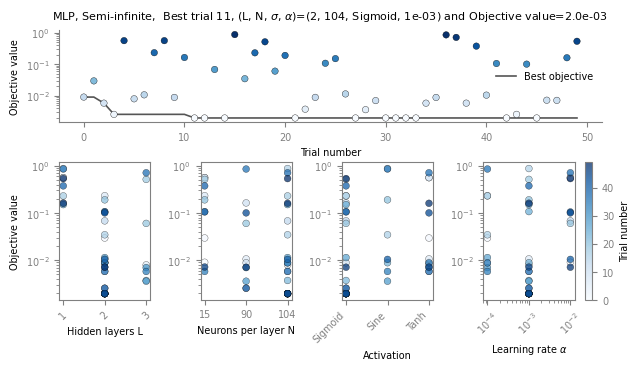

In [17]:
parameter_columns = {
    "hidden_layers": "params_hidden_layers",
    "hidden_units": "params_hidden_units",
    "activation": "params_activation",
    "learning_rate": "params_learning_rate",
}

axis_color = "#808080"
fig = plt.figure(figsize=(7, 3.5))
grid = fig.add_gridspec(2, 1, height_ratios=(1.2, 1.8), hspace=0.35)

ax_history = fig.add_subplot(grid[0, 0])
best_values = trials["objective"].cummin()
objective_min = trials["objective"].min()
objective_max = trials["objective"].max()
objective_norm = LogNorm(vmin=objective_min, vmax=max(objective_max, objective_min * 1.01))
ax_history.plot(trials["number"], best_values, color="#555555", linewidth=1.2, label="Best objective")
ax_history.scatter(trials["number"], trials["objective"], c=trials["objective"], cmap="Blues", norm=objective_norm, edgecolors="black", linewidths=0.25, s=22, zorder=2)
best_configuration = (
    f"MLP, Semi-infinite,  Best trial {int(best_trial['number'])}, "
    f"(L, N, $\sigma$, $\\alpha$)=({int(best_trial['params_hidden_layers'])},"
    f" {int(best_trial['params_hidden_units'])},"
    f" {best_trial['params_activation']},"
    f" {best_trial['params_learning_rate']:.0e}) and "
    f"Objective value={best_trial['objective']:.1e}"
)
ax_history.set_title(best_configuration, fontsize=8, pad=8)
ax_history.spines["top"].set_visible(False)
ax_history.spines["right"].set_visible(False)
ax_history.set_yscale("log")
ax_history.set_ylabel("Objective value", fontsize=7)
ax_history.set_xlabel("Trial number", fontsize=7)
ax_history.legend(frameon=False, fontsize=7)
ax_history.tick_params(axis="both", which="both", labelsize=7, colors=axis_color)
for spine in ax_history.spines.values():
    spine.set_color(axis_color)

parameters = list(parameter_columns)
slice_grid = grid[1, 0].subgridspec(1, len(parameters), wspace=0.55)
axes = [fig.add_subplot(slice_grid[0, index]) for index in range(len(parameters))]
trial_norm = Normalize(trials["number"].min(), trials["number"].max())
labels = {"hidden_layers": "Hidden layers L", "hidden_units": "Neurons per layer N", "activation": "Activation", "learning_rate": r"Learning rate $\alpha$"}

for index, (name, column) in enumerate(parameter_columns.items()):
    axis = axes[index]
    values = trials[column]
    if name == "activation":
        categories = sorted(values.astype(str).unique())
        category_positions = {category: position for position, category in enumerate(categories)}
        x_values = values.astype(str).map(category_positions)
        axis.set_xticks(range(len(categories)))
        axis.set_xticklabels(categories, rotation=45, ha="right")
    elif name == "hidden_units":
        categories = [15, 90, 104]
        category_positions = {value: position for position, value in enumerate(categories)}
        numeric_values = pd.to_numeric(values)
        x_values = numeric_values.map(category_positions)
        axis.set_xticks(range(len(categories)))
        axis.set_xticklabels([str(value) for value in categories])
    else:
        x_values = pd.to_numeric(values)

    scatter = axis.scatter(x_values, trials["objective"], c=trials["number"], cmap="Blues", norm=trial_norm, edgecolors="black", linewidths=0.25, alpha=0.75, s=24)
    axis.set_yscale("log")
    axis.set_xlabel(labels[name], fontsize=7)
    if index == 0:
        axis.set_ylabel("Objective value", fontsize=7)
    axis.tick_params(axis="both", which="both", labelsize=7, colors=axis_color)
    for spine in axis.spines.values():
        spine.set_color(axis_color)
    if name == "learning_rate":
        axis.set_xscale("log")
    if name not in {"activation", "hidden_units"} and values.nunique() <= 10:
        axis.set_xticks(sorted(pd.to_numeric(values).unique()))
        axis.tick_params(axis="x", rotation=45)

colorbar = fig.colorbar(scatter, ax=axes, pad=0.02, fraction=0.03)
colorbar.set_label("Trial number", fontsize=7, color='black')
colorbar.ax.tick_params(labelsize=7, colors=axis_color)
colorbar.outline.set_edgecolor(axis_color)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
plt.savefig(figure_dir / "mlp_semi_infinite_hyperparameter_optimization.svg", dpi=300, bbox_inches="tight")
plt.savefig(figure_dir / "mlp_semi_infinite_hyperparameter_optimization.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Build the LaTeX summary table of optimal hyperparameters

In [16]:
def sci_notation(value, sig_figs=3):
    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / (10 ** exponent)
    return f"${mantissa:.{sig_figs - 1}f}\\times10^{{{exponent}}}$"


def best_from_summary_metrics(csv_path, model_type):
    df = pd.read_csv(csv_path)
    best = df.loc[df["mean_global_error"].idxmin()]
    # MLP has no grid/spline order, so the grid column shows the activation instead.
    grid = (
        str(best["activation"]).replace("()", "")
        if model_type == "MLP"
        else ("--" if pd.isna(best["grid_size"]) else int(best["grid_size"]))
    )
    return {
        "layers": int(best["hidden_layers"]),
        "width": int(best["hidden_units"]),
        "grid": grid,
        "order": "--" if pd.isna(best["spline_order"]) else int(best["spline_order"]),
        "lr": best["adam_lr"],
        "e_global": best["mean_global_error"],
    }


def best_from_optuna_study(csv_path, model_type):
    df = pd.read_csv(csv_path)
    df = df[df["state"].eq("COMPLETE")]
    best = df.loc[df["value"].idxmin()]
    grid = str(best["params_activation"]) if model_type == "MLP" else "--"
    return {
        "layers": int(best["params_hidden_layers"]),
        "width": int(best["params_hidden_units"]),
        "grid": grid,
        "order": "--",
        "lr": best["params_learning_rate"],
        "e_global": best["value"],
    }


rows = [
    ("KAN", "Infinite", best_from_summary_metrics(
        Path("results_kan_infinite_optuna_2026-09-20_01-43-35") / "summary_metrics.csv", "KAN"
    )),
    ("KAN", "Semi-infinite", best_from_summary_metrics(
        Path("results_kan_semi_infinite_optuna_2026-09-20_20-46-49") / "summary_metrics.csv", "KAN"
    )),
    ("MLP", "Infinite", best_from_summary_metrics(
        Path("results_mlp_infinite_optuna_2026-09-20_08-52-35") / "summary_metrics.csv", "MLP"
    )),
    ("MLP", "Semi-infinite", best_from_optuna_study(
        Path("results_mlp_semi_infinite_optuna_2026-09-20_07-42-39") / "data" / "study_completed_sorted.csv", "MLP"
    )),
]

lines = [
    r"\begin{table*}[ht!]",
    r"    \centering",
    r"    \sffamily\small",
    r"    \caption{Optimal hyperparameter configurations identified using Optuna for",
    r"    the infinite and semi-infinite problems.}",
    r"    \label{tab:kan_optimal_configurations}",
    r"    \begin{tabular}{lccccccc}",
    r"        \hline",
    r"        Model & Domain & L & N & G or $\sigma$ & k &",
    r"        $\alpha$ & Objective value \\",
    r"        \hline",
]
for model, domain, cfg in rows:
    lines.append(
        f"        {model} & {domain} & {cfg['layers']} & {cfg['width']} & "
        f"{cfg['grid']} & {cfg['order']} & {sci_notation(cfg['lr'])} & "
        f"{sci_notation(cfg['e_global'])} \\\\"
    )
lines += [
    r"        \hline",
    r"    \end{tabular}",
    r"\end{table*}",
]

latex_table = "\n".join(lines)
print(latex_table)


\begin{table*}[ht!]
    \centering
    \sffamily\small
    \caption{Optimal hyperparameter configurations identified using Optuna for
    the infinite and semi-infinite problems.}
    \label{tab:kan_optimal_configurations}
    \begin{tabular}{lccccccc}
        \hline
        Model & Domain & L & N & G or $\sigma$ & k &
        $\alpha$ & Objective value \\
        \hline
        KAN & Infinite & 3 & 15 & 5 & 4 & $1.00\times10^{-4}$ & $1.75\times10^{-3}$ \\
        KAN & Semi-infinite & 3 & 15 & 5 & 3 & $1.00\times10^{-2}$ & $8.38\times10^{-4}$ \\
        MLP & Infinite & 3 & 90 & Sine & -- & $1.00\times10^{-3}$ & $1.32\times10^{-3}$ \\
        MLP & Semi-infinite & 2 & 104 & Sigmoid & -- & $1.00\times10^{-3}$ & $1.97\times10^{-3}$ \\
        \hline
    \end{tabular}
\end{table*}
